In [1]:
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization

![](https://github.com/StrixzIV/01416417-deep-learning-and-application/blob/main/assets/IMG_7885.JPG?raw=true)

In [2]:
# section 1
# Hyperparameters

learning_rate = 0.001
batch_size = 128
num_epochs = 500

In [3]:
# section 2
# Load the MNIST dataset and normalize the pixel values to be between 0 and 1

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [4]:
# section 3
# Split the training set into a training set and a validation set with a ratio of 9:1 
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.1, random_state = 42)

In [5]:
# section 4
# Define a model architecture with hidden layer

input_shape = (28, 28)
num_classes = 10

model = Sequential([

    Flatten(input_shape=input_shape),

    Dense(512, activation='relu', kernel_initializer=initializers.GlorotUniform()),
    BatchNormalization(),
    Dropout(0.2),

    Dense(256, activation='relu', kernel_initializer=initializers.GlorotUniform()),
    BatchNormalization(),
    
    Dense(num_classes, activation='softmax')

])

/Users/jikaewsi/miniforge3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# section 5
# print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,890 (2.06 MB)

 Trainable params: 537,354 (2.05 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [7]:
# section 6
# Define loss
loss = 'sparse_categorical_crossentropy'

In [8]:
# section 7
# Define an optimizer
optimizer = Adam(learning_rate=learning_rate)

In [9]:
# Bonus: Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [10]:
# section 8
# compile the model
model.compile(
    optimizer=optimizer,
	loss=loss,
	metrics=['accuracy']
)

In [11]:
# section 9
# train the model
history = model.fit(
	x_train,
	y_train,
	epochs=num_epochs,
	validation_data = (x_val, y_val),
	callbacks=[early_stop],
	batch_size = batch_size
)

Epoch 1/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9361 - loss: 0.2076 - val_accuracy: 0.9693 - val_loss: 0.1000
Epoch 2/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9729 - loss: 0.0892 - val_accuracy: 0.9755 - val_loss: 0.0799
Epoch 3/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9796 - loss: 0.0661 - val_accuracy: 0.9762 - val_loss: 0.0790
Epoch 4/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9823 - loss: 0.0537 - val_accuracy: 0.9762 - val_loss: 0.0778
Epoch 5/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0412 - val_accuracy: 0.9820 - val_loss: 0.0663
Epoch 6/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0371 - val_accuracy: 0.9778 - val_loss: 0.0731
Epoch 7/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9889 - loss: 0.0338 - val_accuracy: 0.9788 - val_loss: 0.0712
Epoch 8/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9900 - loss: 0.0304 - val_accu

In [12]:
# section 10
# evaluate test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'test_acc: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.9817 - loss: 0.0663
test_acc: 0.9817


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step
Misclassified samples: 183


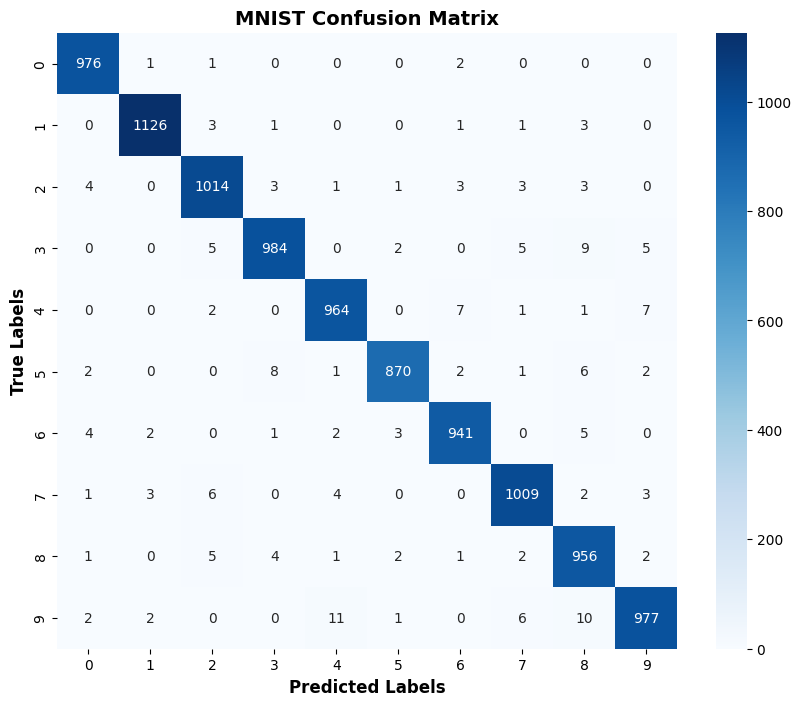

In [13]:
# Bonus No.2 - Confusion Matrix

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

n_misclassified = 0

for (i, row) in enumerate(cm):
    
	for (j, e) in enumerate(row):
     
		if (i == j):
			continue

		n_misclassified += e
  
print(f'Misclassified samples: {n_misclassified}')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')

plt.show()